# Build RFM Table

RFM (Recency, Frequency, Monetary) is one of the most widely used customer segmentation techniques in retail analytics.

It measures:

- **Recency (R):** How recently a customer made a purchase.
- **Frequency (F):** How often the customer purchases.
- **Monetary (M):** How much the customer spends.

The resulting RFM table will be used for clustering customers into meaningful business segments.

In [1]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import pickle

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
# ==========================================================
# Project Configuration
# ==========================================================

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

MODELS_DIR = PROJECT_ROOT / "models"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Project Root :", PROJECT_ROOT)
print("Processed Data :", PROCESSED_DIR)
print("Figures :", FIGURES_DIR)
print("Models :", MODELS_DIR)

Project Root : c:\N_VsCode\Zidio Project\PROJECT\RetailPulse-AI-Customer-Analytics
Processed Data : c:\N_VsCode\Zidio Project\PROJECT\RetailPulse-AI-Customer-Analytics\data\processed
Figures : c:\N_VsCode\Zidio Project\PROJECT\RetailPulse-AI-Customer-Analytics\reports\figures
Models : c:\N_VsCode\Zidio Project\PROJECT\RetailPulse-AI-Customer-Analytics\models


In [3]:
# ==========================================================
# Load Processed Dataset
# ==========================================================

data_path = PROCESSED_DIR / "retail_cleaned.csv"

df = pd.read_csv(
    data_path,
    parse_dates=["InvoiceDate"]
)

print("=" * 70)
print("DATA LOADED SUCCESSFULLY")
print("=" * 70)

print(f"Shape : {df.shape}")

display(df.head())

DATA LOADED SUCCESSFULLY
Shape : (779425, 22)


,InvoiceID,StockCode,ProductDescription,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,InvoiceYear,...,MonthName,InvoiceWeek,InvoiceDay,DayName,InvoiceHour,IsWeekend,CustomerCountry,InvoiceMonthYear,BasketSize,BasketValue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,...,December,49,1,Tuesday,7,False,United Kingdom,2009-12,8,505.3
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,...,December,49,1,Tuesday,7,False,United Kingdom,2009-12,8,505.3
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,...,December,49,1,Tuesday,7,False,United Kingdom,2009-12,8,505.3
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,...,December,49,1,Tuesday,7,False,United Kingdom,2009-12,8,505.3
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,...,December,49,1,Tuesday,7,False,United Kingdom,2009-12,8,505.3


In [4]:
# ==========================================================
# Dataset Validation
# ==========================================================

print("=" * 70)
print("DATASET VALIDATION")
print("=" * 70)

print(f"Rows                : {len(df):,}")
print(f"Columns             : {df.shape[1]}")
print(f"Unique Customers    : {df['CustomerID'].nunique():,}")
print(f"Unique Products     : {df['StockCode'].nunique():,}")
print(f"Unique Invoices     : {df['InvoiceID'].nunique():,}")

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

DATASET VALIDATION
Rows                : 779,425
Columns             : 22
Unique Customers    : 5,878
Unique Products     : 4,631
Unique Invoices     : 36,969

Missing Values
InvoiceID             0
StockCode             0
ProductDescription    0
Quantity              0
InvoiceDate           0
UnitPrice             0
CustomerID            0
Country               0
TotalAmount           0
InvoiceYear           0
InvoiceQuarter        0
InvoiceMonth          0
MonthName             0
InvoiceWeek           0
InvoiceDay            0
DayName               0
InvoiceHour           0
IsWeekend             0
CustomerCountry       0
InvoiceMonthYear      0
BasketSize            0
BasketValue           0
dtype: int64

Duplicate Rows
0


In [5]:
# ==========================================================
# Reference Date
# ==========================================================

reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

print("=" * 60)
print("REFERENCE DATE")
print("=" * 60)
print(reference_date)

REFERENCE DATE
2011-12-10 12:50:00


In [6]:
# ==========================================================
# Create RFM Table
# ==========================================================

rfm = (
    df.groupby("CustomerID")
      .agg(
          Recency=("InvoiceDate",
                   lambda x: (reference_date - x.max()).days),

          Frequency=("InvoiceID", "nunique"),

          Monetary=("TotalAmount", "sum")
      )
      .reset_index()
)

display(rfm.head())

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,4921.53
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40


In [7]:
# ==========================================================
# RFM Dataset Information
# ==========================================================

print("=" * 70)
print("RFM DATASET")
print("=" * 70)

print(f"Customers : {len(rfm):,}")
print(f"Columns   : {rfm.shape[1]}")

print("\nMissing Values")

print(rfm.isnull().sum())

print("\nDuplicate Customers")

print(rfm["CustomerID"].duplicated().sum())

RFM DATASET
Customers : 5,878
Columns   : 4

Missing Values
CustomerID    0
Recency       0
Frequency     0
Monetary      0
dtype: int64

Duplicate Customers
0


# RFM Statistics

Before applying clustering, it is important to understand the distribution of Recency, Frequency, and Monetary values.

This helps identify skewness, extreme values, and customer purchasing behavior.

In [8]:
# ==========================================================
# RFM Summary Statistics
# ==========================================================

display(
    rfm.describe().T
)

,count,mean,std,min,25%,50%,75%,max
CustomerID,5878.0,15315.313542,1715.572666,12346.00,13833.25,15314.50,16797.750,18287.00
Recency,5878.0,201.331916,209.338707,1.00,26.00,96.00,380.000,739.00
Frequency,5878.0,6.289384,13.009406,1.00,1.00,3.00,7.000,398.00
Monetary,5878.0,2955.904095,14440.852688,2.95,342.28,867.74,2248.305,580987.04


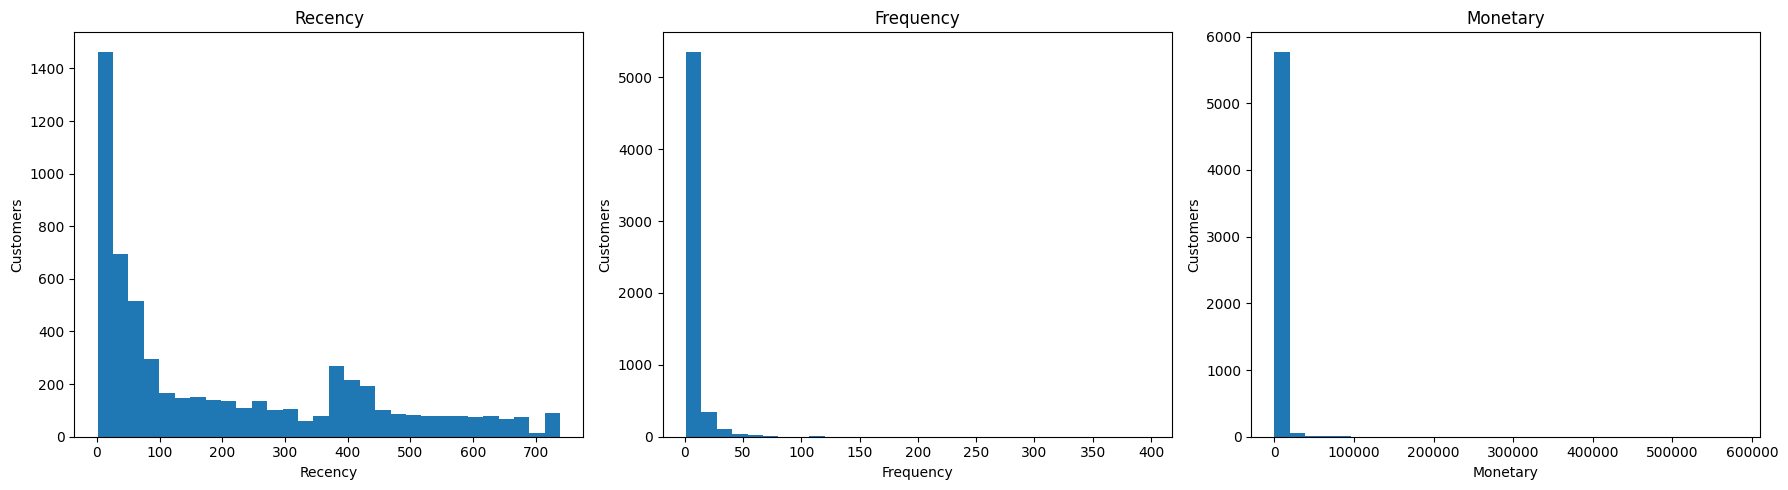

In [9]:
# ==========================================================
# RFM Distribution
# ==========================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

columns = ["Recency", "Frequency", "Monetary"]

for ax, column in zip(axes, columns):

    ax.hist(
        rfm[column],
        bins=30
    )

    ax.set_title(column)
    ax.set_xlabel(column)
    ax.set_ylabel("Customers")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "rfm_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Outlier Analysis

Retail transaction data naturally contains extreme customer behaviors.

Instead of removing these observations, we first quantify the number of outliers using the Interquartile Range (IQR) method.

This helps us understand the data distribution before applying transformations.

In [10]:
# ==========================================================
# IQR Outlier Analysis
# ==========================================================

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower) |
        (data[column] > upper)
    ]

    return len(outliers), lower, upper


for col in ["Recency", "Frequency", "Monetary"]:

    count, lower, upper = detect_outliers_iqr(rfm, col)

    print("=" * 60)
    print(col)
    print("=" * 60)
    print(f"Lower Bound : {lower:.2f}")
    print(f"Upper Bound : {upper:.2f}")
    print(f"Outliers    : {count:,}")

Recency
Lower Bound : -505.00
Upper Bound : 911.00
Outliers    : 0
Frequency
Lower Bound : -8.00
Upper Bound : 16.00
Outliers    : 427
Monetary
Lower Bound : -2516.76
Upper Bound : 5107.34
Outliers    : 633


# Log Transformation

Frequency and Monetary are highly skewed.

A logarithmic transformation compresses extremely large values while preserving the relative ordering of customers.

Recency is left unchanged because its distribution already carries meaningful temporal information.

In [11]:
# ==========================================================
# Log Transformation
# ==========================================================

rfm_log = rfm.copy()

rfm_log["Frequency"] = np.log1p(rfm_log["Frequency"])
rfm_log["Monetary"] = np.log1p(rfm_log["Monetary"])

display(rfm_log.head())

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,2.564949,11.258774
1,12347.0,2,2.197225,8.501578
2,12348.0,75,1.791759,7.611051
3,12349.0,19,1.609438,8.396085
4,12350.0,310,0.693147,5.815324


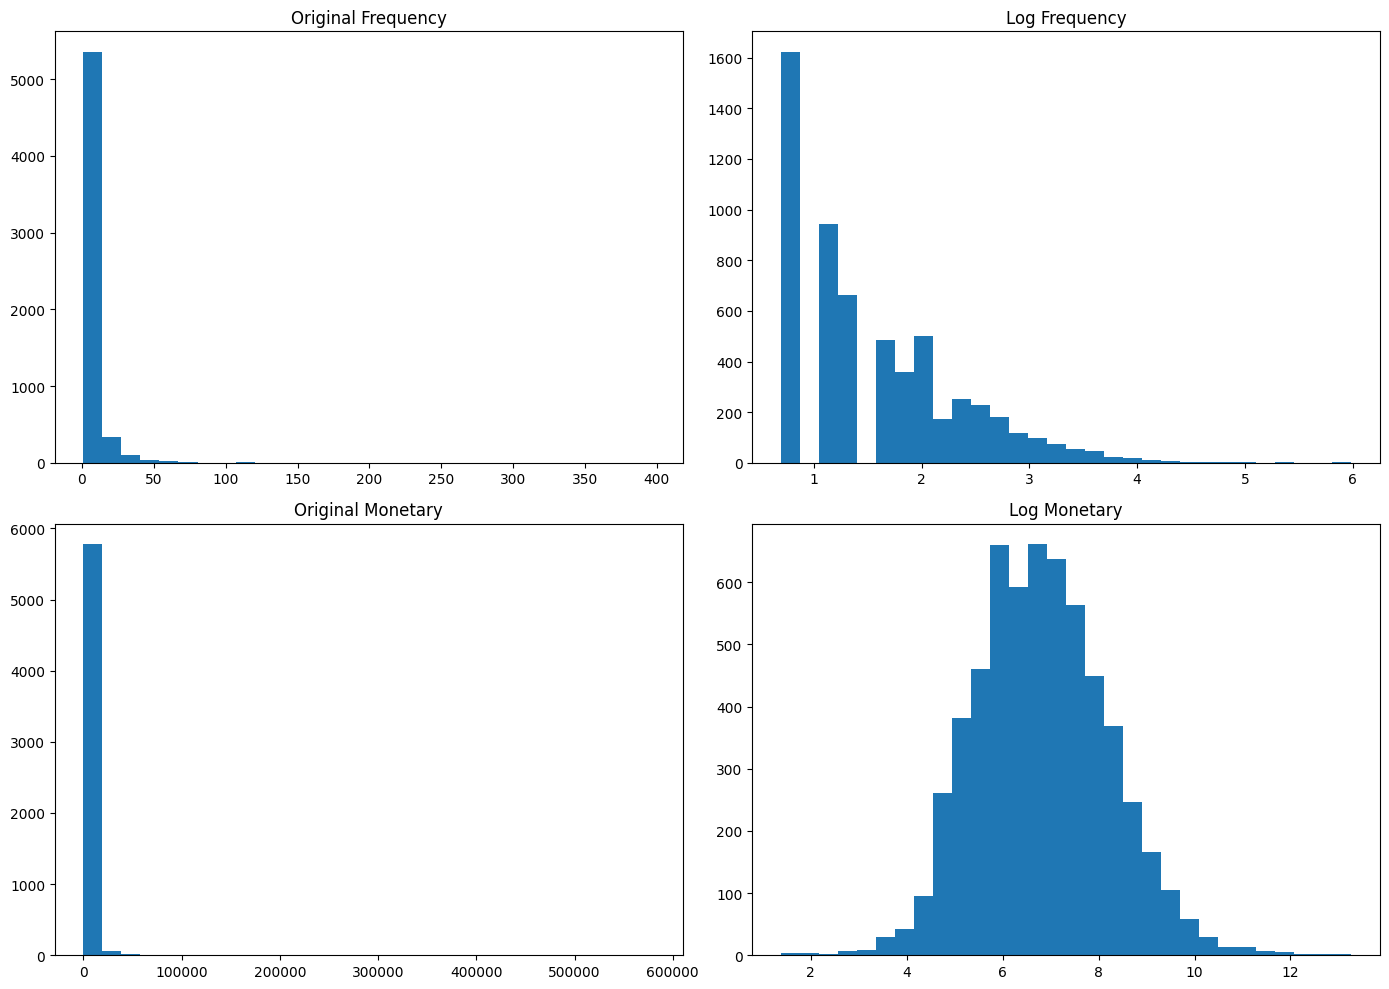

In [12]:
# ==========================================================
# Compare Before vs After Transformation
# ==========================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(rfm["Frequency"], bins=30)
axes[0, 0].set_title("Original Frequency")

axes[0, 1].hist(rfm_log["Frequency"], bins=30)
axes[0, 1].set_title("Log Frequency")

axes[1, 0].hist(rfm["Monetary"], bins=30)
axes[1, 0].set_title("Original Monetary")

axes[1, 1].hist(rfm_log["Monetary"], bins=30)
axes[1, 1].set_title("Log Monetary")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "log_transformation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Feature Scaling

K-Means clustering is distance-based.

Without scaling, Monetary would dominate the clustering process because it has a much larger numerical range than Recency or Frequency.

Standardization ensures that all three features contribute equally.

In [13]:
# ==========================================================
# Standardization
# ==========================================================

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm_log[["Recency", "Frequency", "Monetary"]]
)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=["Recency", "Frequency", "Monetary"]
)

display(rfm_scaled.head())

,Recency,Frequency,Monetary
0,0.595584,1.254496,3.206219
1,-0.952279,0.800166,1.215993
2,-0.603532,0.299207,0.573185
3,-0.871064,0.073946,1.139846
4,0.519146,-1.058146,-0.723024


In [14]:
# ==========================================================
# Verify Standardized Features
# ==========================================================

display(rfm_scaled.describe().T)

,count,mean,std,min,25%,50%,75%,max
Recency,5878.0,-4.230860e-17,1.000085,-0.957056,-0.837623,-0.503208,0.853561,2.568631
Frequency,5878.0,2.381370e-16,1.000085,-1.058146,-1.058146,-0.201751,0.654643,5.484918
Monetary,5878.0,3.771510e-16,1.000085,-3.929108,-0.706261,-0.036045,0.650656,4.659776


# Correlation Analysis

Before clustering, we examine the relationship between the transformed RFM features.

Highly correlated features may bias distance-based clustering algorithms.

This analysis confirms that each feature contributes unique information to customer segmentation.

In [15]:
# ==========================================================
# Correlation Matrix
# ==========================================================

correlation = rfm_log[["Recency", "Frequency", "Monetary"]].corr()

display(correlation)

,Recency,Frequency,Monetary
Recency,1.000000,-0.504744,-0.480431
Frequency,-0.504744,1.000000,0.849925
Monetary,-0.480431,0.849925,1.000000


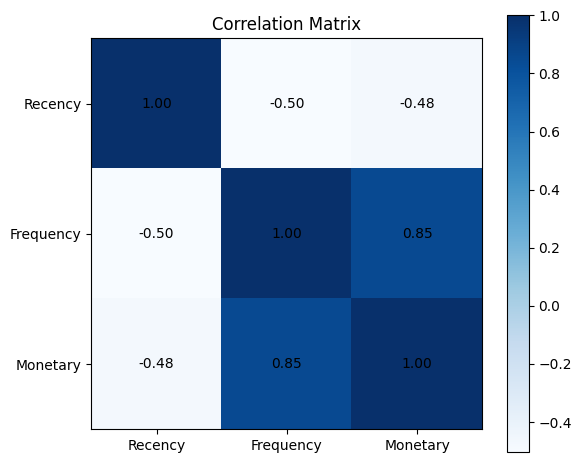

In [16]:
# ==========================================================
# Correlation Heatmap
# ==========================================================

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(correlation, cmap="Blues")

ax.set_xticks(range(len(correlation.columns)))
ax.set_yticks(range(len(correlation.columns)))

ax.set_xticklabels(correlation.columns)
ax.set_yticklabels(correlation.columns)

for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        ax.text(
            j,
            i,
            f"{correlation.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="black"
        )

plt.colorbar(im)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "rfm_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Selecting the Optimal Number of Clusters

Choosing the correct number of clusters is one of the most important steps in K-Means clustering.

Rather than selecting an arbitrary value, we evaluate multiple cluster counts using:

- **Elbow Method** to measure within-cluster variance.
- **Silhouette Score** to measure cluster quality and separation.

The final value of **K** will be selected based on these validation techniques together with business interpretability.

In [17]:
# ==========================================================
# Elbow Method
# ==========================================================

inertia = []

cluster_range = range(2, 11)

for k in cluster_range:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    model.fit(rfm_scaled)

    inertia.append(model.inertia_)

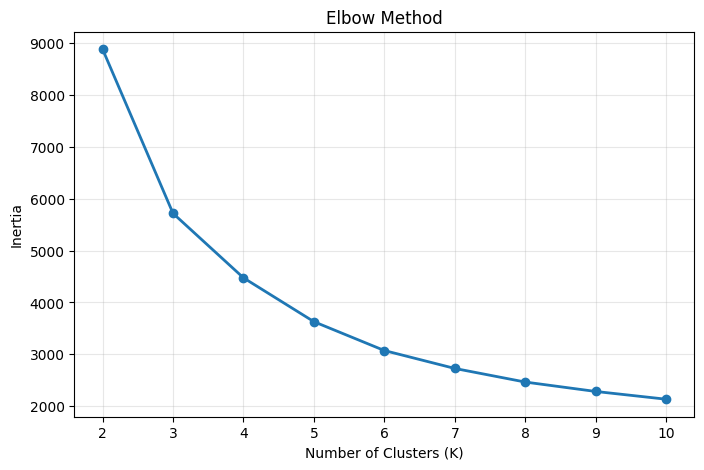

In [18]:
# ==========================================================
# Elbow Curve
# ==========================================================

plt.figure(figsize=(8, 5))

plt.plot(
    cluster_range,
    inertia,
    marker="o",
    linewidth=2
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.grid(alpha=0.3)

plt.savefig(
    FIGURES_DIR / "elbow_method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
# ==========================================================
# Silhouette Analysis
# ==========================================================

silhouette_scores = []

for k in cluster_range:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(rfm_scaled)

    score = silhouette_score(
        rfm_scaled,
        labels
    )

    silhouette_scores.append(score)

,Clusters,Silhouette Score
0,2,0.418681
1,3,0.400998
2,4,0.361612
3,5,0.366417
4,6,0.348269
5,7,0.335343
6,8,0.316359
7,9,0.309349
8,10,0.295447


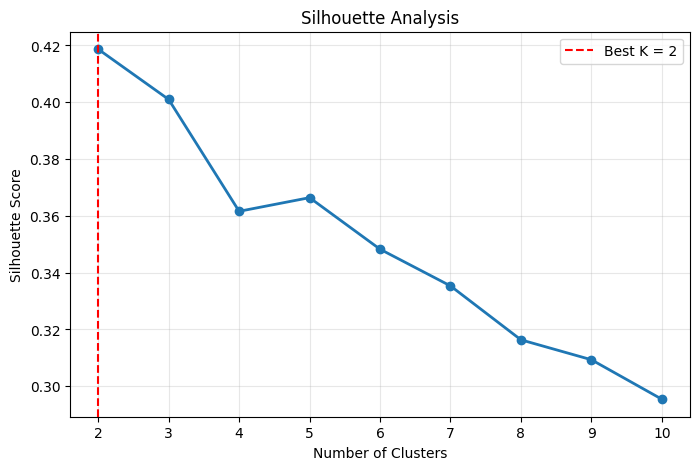

Recommended Number of Clusters : 2


In [20]:
# ==========================================================
# Silhouette Score Plot
# ==========================================================

results = pd.DataFrame({
    "Clusters": list(cluster_range),
    "Silhouette Score": silhouette_scores
})

display(results)

plt.figure(figsize=(8, 5))

plt.plot(
    results["Clusters"],
    results["Silhouette Score"],
    marker="o",
    linewidth=2
)

best_k = results.loc[
    results["Silhouette Score"].idxmax(),
    "Clusters"
]

plt.axvline(
    best_k,
    color="red",
    linestyle="--",
    label=f"Best K = {best_k}"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.legend()

plt.grid(alpha=0.3)

plt.savefig(
    FIGURES_DIR / "silhouette_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("=" * 60)
print(f"Recommended Number of Clusters : {best_k}")
print("=" * 60)

In [21]:
# ==========================================================
# Save Cluster Validation Results
# ==========================================================

cluster_validation = results.copy()

cluster_validation["Inertia"] = inertia

display(cluster_validation)

cluster_validation.to_csv(
    PROCESSED_DIR / "cluster_validation.csv",
    index=False
)

print("Cluster validation results saved successfully.")

,Clusters,Silhouette Score,Inertia
0,2,0.418681,8880.656360
1,3,0.400998,5716.039021
2,4,0.361612,4473.009537
3,5,0.366417,3627.771376
4,6,0.348269,3071.681511
5,7,0.335343,2726.342355
6,8,0.316359,2464.127469
7,9,0.309349,2282.792225
8,10,0.295447,2133.365979


Cluster validation results saved successfully.


# Final K-Means Model

Based on the clustering validation results and business interpretability, the final K-Means model is trained using **4 clusters**.

The resulting cluster assignments will be analyzed and translated into meaningful customer segments.

In [22]:
# ==========================================================
# Train Final K-Means Model
# ==========================================================

FINAL_K = 4

kmeans = KMeans(
    n_clusters=FINAL_K,
    random_state=42,
    n_init=20
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

print("=" * 60)
print("FINAL MODEL TRAINED")
print("=" * 60)
print(f"Number of Clusters : {FINAL_K}")

FINAL MODEL TRAINED
Number of Clusters : 4


In [23]:
# ==========================================================
# Save K-Means Model
# ==========================================================

with open(MODELS_DIR / "kmeans_model.pkl", "wb") as file:
    pickle.dump(kmeans, file)

print("K-Means model saved successfully.")

K-Means model saved successfully.


# Cluster Distribution

Before interpreting the clusters, we examine how customers are distributed across the four groups.

Balanced clusters generally indicate a stable segmentation model, while extremely small clusters may represent niche customer groups.

In [24]:
# ==========================================================
# Cluster Distribution
# ==========================================================

cluster_counts = (
    rfm["Cluster"]
    .value_counts()
    .sort_index()
    .rename("Customers")
    .reset_index()
    .rename(columns={"index": "Cluster"})
)

cluster_counts["Percentage"] = (
    cluster_counts["Customers"] /
    cluster_counts["Customers"].sum() * 100
).round(2)

display(cluster_counts)

,Cluster,Customers,Percentage
0,0,1494,25.42
1,1,1646,28.00
2,2,876,14.90
3,3,1862,31.68


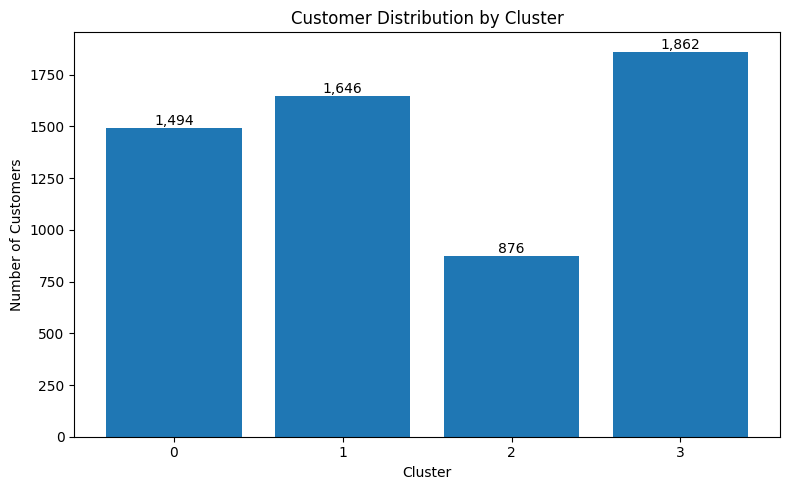

In [25]:
# ==========================================================
# Cluster Distribution Plot
# ==========================================================

plt.figure(figsize=(8,5))

bars = plt.bar(
    cluster_counts["Cluster"].astype(str),
    cluster_counts["Customers"]
)

plt.title("Customer Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "segment_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Cluster Profiling

Cluster labels generated by K-Means have no business meaning.

To understand each cluster, we compute the average Recency, Frequency, and Monetary values for every group.

These profiles will later be translated into meaningful customer segment names.

In [26]:
# ==========================================================
# Cluster Profiles
# ==========================================================

cluster_profile = (
    rfm.groupby("Cluster")
       .agg(
           Customers=("CustomerID", "count"),
           Avg_Recency=("Recency", "mean"),
           Avg_Frequency=("Frequency", "mean"),
           Avg_Monetary=("Monetary", "mean")
       )
       .round(2)
)

display(cluster_profile)

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,1494,102.93,1.84,460.73
1,1646,492.13,1.70,521.33
2,876,38.35,23.42,13656.68
3,1862,99.90,5.85,2075.78


In [27]:
# ==========================================================
# Normalized Cluster Profiles
# ==========================================================

profile_normalized = (
    cluster_profile[
        ["Avg_Recency",
         "Avg_Frequency",
         "Avg_Monetary"]
    ]
)

display(profile_normalized)

,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,
0,102.93,1.84,460.73
1,492.13,1.70,521.33
2,38.35,23.42,13656.68
3,99.90,5.85,2075.78


# Customer Segment Naming

The numerical cluster labels generated by K-Means are translated into descriptive business segments.

These names are based on the average Recency, Frequency, and Monetary characteristics of each cluster and are intended to support business decision-making and marketing strategies.

In [28]:
# ==========================================================
# Assign Business Segment Names
# ==========================================================

segment_mapping = {
    0: "Potential Customers",
    1: "At Risk Customers",
    2: "Champions",
    3: "Loyal Customers"
}

rfm["Segment"] = rfm["Cluster"].map(segment_mapping)

display(
    rfm[
        [
            "CustomerID",
            "Cluster",
            "Segment",
            "Recency",
            "Frequency",
            "Monetary"
        ]
    ].head()
)

,CustomerID,Cluster,Segment,Recency,Frequency,Monetary
0,12346.0,2,Champions,326,12,77556.46
1,12347.0,3,Loyal Customers,2,8,4921.53
2,12348.0,3,Loyal Customers,75,5,2019.40
3,12349.0,3,Loyal Customers,19,4,4428.69
4,12350.0,1,At Risk Customers,310,1,334.40


In [29]:
# ==========================================================
# Segment Summary
# ==========================================================

segment_summary = (
    rfm.groupby("Segment")
       .agg(
           Customers=("CustomerID", "count"),
           Avg_Recency=("Recency", "mean"),
           Avg_Frequency=("Frequency", "mean"),
           Avg_Monetary=("Monetary", "mean")
       )
       .round(2)
       .sort_values("Avg_Monetary", ascending=False)
)

display(segment_summary)

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Segment,,,,
Champions,876,38.35,23.42,13656.68
Loyal Customers,1862,99.90,5.85,2075.78
At Risk Customers,1646,492.13,1.70,521.33
Potential Customers,1494,102.93,1.84,460.73


In [30]:
# ==========================================================
# Segment Distribution
# ==========================================================

segment_distribution = (
    rfm["Segment"]
    .value_counts()
    .reset_index()
)

segment_distribution.columns = [
    "Segment",
    "Customers"
]

display(segment_distribution)

,Segment,Customers
0,Loyal Customers,1862
1,At Risk Customers,1646
2,Potential Customers,1494
3,Champions,876


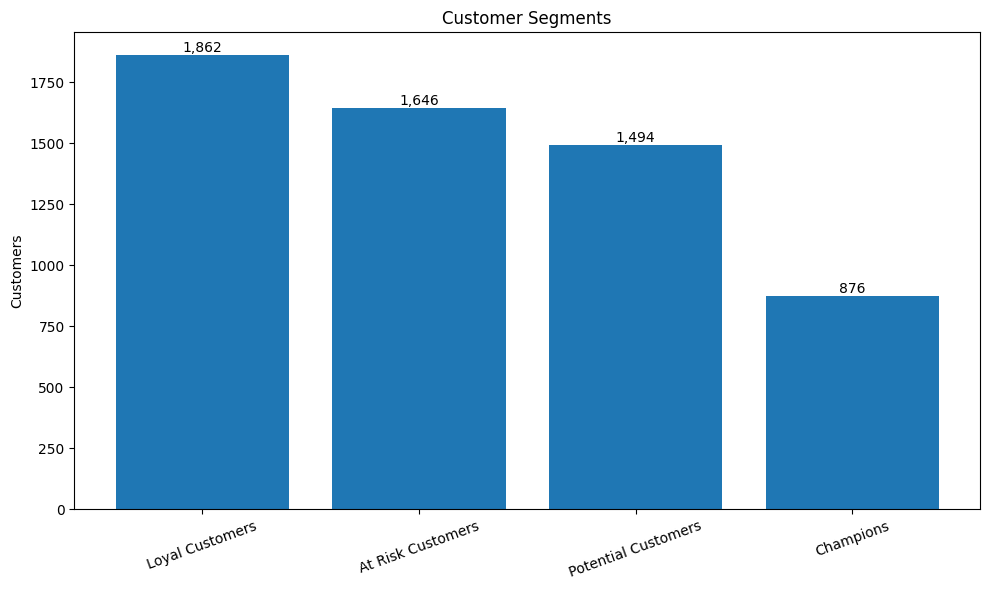

In [31]:
# ==========================================================
# Segment Distribution Chart
# ==========================================================

plt.figure(figsize=(10,6))

bars = plt.bar(
    segment_distribution["Segment"],
    segment_distribution["Customers"]
)

plt.xticks(rotation=20)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom"
    )

plt.title("Customer Segments")

plt.ylabel("Customers")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "customer_segments.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Cluster Visualization using Principal Component Analysis (PCA)

The RFM feature space is three-dimensional, making it difficult to visualize customer clusters directly.

Principal Component Analysis (PCA) reduces the data into two principal components while preserving as much variance as possible.

This allows us to visually inspect the quality and separation of the customer clusters.

In [32]:
# ==========================================================
# Import PCA
# ==========================================================

from sklearn.decomposition import PCA

In [33]:
# ==========================================================
# Apply PCA
# ==========================================================

pca = PCA(n_components=2, random_state=42)

pca_features = pca.fit_transform(rfm_scaled)

pca_df = pd.DataFrame(
    pca_features,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = rfm["Cluster"]
pca_df["Segment"] = rfm["Segment"]

display(pca_df.head())

,PC1,PC2,Cluster,Segment
0,2.453285,2.107661,2,Champions
1,1.708111,-0.122591,3,Loyal Customers
2,0.832567,-0.217744,3,Loyal Customers
3,1.171779,-0.314482,3,Loyal Customers
4,-1.353327,-0.156229,1,At Risk Customers


In [34]:
# ==========================================================
# Explained Variance
# ==========================================================

variance = pca.explained_variance_ratio_

print("=" * 60)
print("PCA EXPLAINED VARIANCE")
print("=" * 60)

for i, value in enumerate(variance, start=1):
    print(f"PC{i}: {value:.4f}")

print("-" * 60)
print(f"Total Variance: {variance.sum():.4f}")

PCA EXPLAINED VARIANCE
PC1: 0.7470
PC2: 0.2031
------------------------------------------------------------
Total Variance: 0.9501


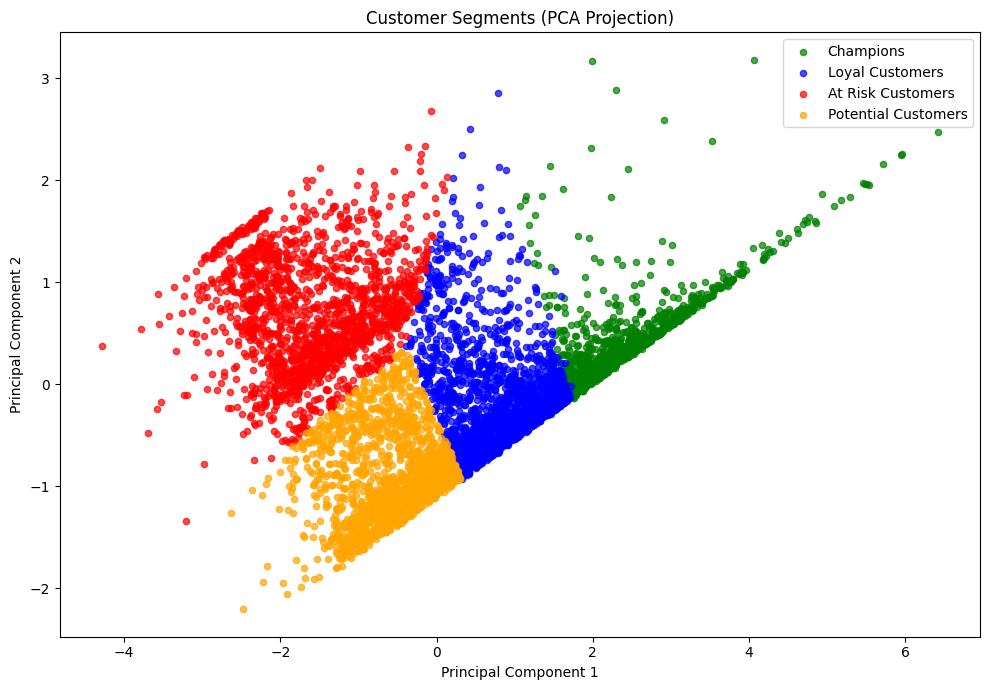

In [35]:
# ==========================================================
# PCA Scatter Plot
# ==========================================================

plt.figure(figsize=(10,7))

colors = {
    "Champions": "green",
    "Loyal Customers": "blue",
    "Potential Customers": "orange",
    "At Risk Customers": "red"
}

for segment in pca_df["Segment"].unique():

    subset = pca_df[pca_df["Segment"] == segment]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=segment,
        alpha=0.7,
        s=20,
        color=colors.get(segment)
    )

plt.title("Customer Segments (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend()

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "customer_segments_pca.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Segment Profile Comparison

Comparing the average RFM values across customer segments provides a clear understanding of how customer behavior differs between groups.

These profiles support targeted business and marketing strategies.

In [36]:
# ==========================================================
# Segment Profile Comparison
# ==========================================================

segment_profile = (
    rfm.groupby("Segment")[["Recency", "Frequency", "Monetary"]]
       .mean()
       .round(2)
)

display(segment_profile)

,Recency,Frequency,Monetary
Segment,,,
At Risk Customers,492.13,1.70,521.33
Champions,38.35,23.42,13656.68
Loyal Customers,99.90,5.85,2075.78
Potential Customers,102.93,1.84,460.73


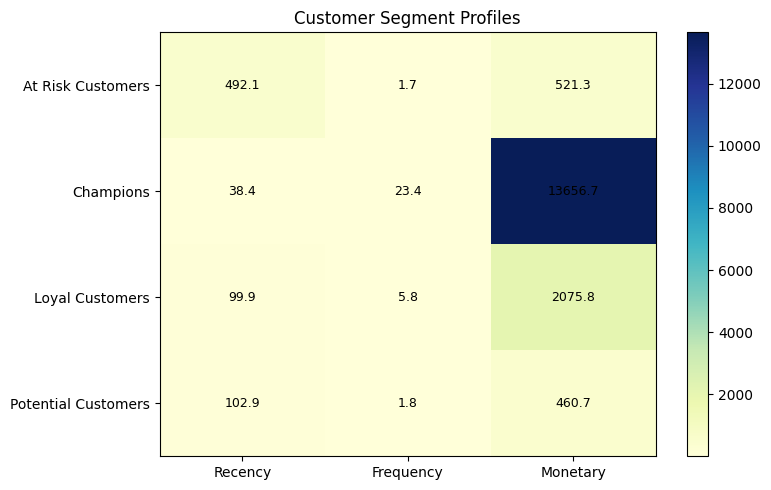

In [37]:
# ==========================================================
# Segment Profile Heatmap
# ==========================================================

plt.figure(figsize=(8,5))

plt.imshow(
    segment_profile,
    aspect="auto",
    cmap="YlGnBu"
)

plt.xticks(
    range(len(segment_profile.columns)),
    segment_profile.columns
)

plt.yticks(
    range(len(segment_profile.index)),
    segment_profile.index
)

for i in range(len(segment_profile.index)):
    for j in range(len(segment_profile.columns)):
        plt.text(
            j,
            i,
            f"{segment_profile.iloc[i,j]:.1f}",
            ha="center",
            va="center",
            fontsize=9
        )

plt.colorbar()

plt.title("Customer Segment Profiles")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "segment_profile_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Export Results

The processed customer segmentation datasets and trained clustering model are exported for reuse in downstream notebooks and the Streamlit dashboard.

These artifacts provide the foundation for churn prediction, recommendation systems, inventory optimization, and customer analytics.

In [38]:
# ==========================================================
# Export Customer RFM Dataset
# ==========================================================

customer_rfm = rfm.copy()

customer_rfm.to_csv(
    PROCESSED_DIR / "customer_rfm.csv",
    index=False
)

print("customer_rfm.csv saved successfully.")

customer_rfm.csv saved successfully.


In [39]:
# ==========================================================
# Export Customer Segments
# ==========================================================

customer_segments = rfm[
    [
        "CustomerID",
        "Cluster",
        "Segment"
    ]
].copy()

customer_segments.to_csv(
    PROCESSED_DIR / "customer_segments.csv",
    index=False
)

print("customer_segments.csv saved successfully.")

customer_segments.csv saved successfully.


In [40]:
# ==========================================================
# Verify Exported Files
# ==========================================================

rfm_check = pd.read_csv(PROCESSED_DIR / "customer_rfm.csv")
segment_check = pd.read_csv(PROCESSED_DIR / "customer_segments.csv")

print("=" * 60)
print("EXPORT VALIDATION")
print("=" * 60)

print(f"Customer RFM Shape      : {rfm_check.shape}")
print(f"Customer Segments Shape : {segment_check.shape}")

assert len(rfm_check) == len(rfm)
assert len(segment_check) == len(rfm)

print("\nAll exported files verified successfully.")

EXPORT VALIDATION
Customer RFM Shape      : (5878, 6)
Customer Segments Shape : (5878, 3)

All exported files verified successfully.


# Business Recommendations

The customer segmentation results can be directly translated into targeted business strategies.

Each customer segment requires a different engagement approach to maximize customer lifetime value and retention.

In [41]:
# ==========================================================
# Business Recommendations
# ==========================================================

recommendations = pd.DataFrame({
    "Segment": [
        "Champions",
        "Loyal Customers",
        "Potential Customers",
        "At Risk Customers"
    ],
    "Recommended Strategy": [
        "Reward with VIP benefits and exclusive offers.",
        "Increase engagement through loyalty programs and cross-selling.",
        "Encourage repeat purchases with personalized promotions.",
        "Launch win-back campaigns using targeted discounts and communication."
    ]
})

display(recommendations)

,Segment,Recommended Strategy
0,Champions,Reward with VIP benefits and exclusive offers.
1,Loyal Customers,Increase engagement through loyalty programs a...
2,Potential Customers,Encourage repeat purchases with personalized p...
3,At Risk Customers,Launch win-back campaigns using targeted disco...


# Notebook Summary

This notebook successfully segmented retail customers using RFM analysis and K-Means clustering.

## Key Achievements

- Built customer-level RFM features.
- Applied logarithmic transformation and feature scaling.
- Evaluated clustering using the Elbow Method and Silhouette Score.
- Trained the final K-Means clustering model.
- Assigned business-friendly customer segment names.
- Visualized customer clusters using Principal Component Analysis.
- Exported reusable datasets and the trained model.

The generated outputs will serve as key inputs for the upcoming notebooks on customer churn prediction, recommendation systems, inventory optimization, and business dashboards.

In [42]:
with open(MODELS_DIR / "scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

In [43]:
with open(MODELS_DIR / "scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)

print("Scaler saved successfully.")

Scaler saved successfully.
